In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

sns.set_style('white')
sns.set_palette('Set2')

# Load and clean data

In [3]:
# train data
train = pd.read_csv('/content/diabetes-train.csv')

# test data
test = pd.read_csv('/content/diabetes-test.csv')

In [4]:
train.shape

(70692, 22)

In [5]:
test.shape

(253680, 22)

In [6]:
train.columns


Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [7]:
test.columns

Index(['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker',
       'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies',
       'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth',
       'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education',
       'Income'],
      dtype='object')

In [8]:
# check missing values
train.isnull().sum()

,0
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [9]:
test.isnull().sum()

,0
Diabetes_binary,0
HighBP,0
HighChol,0
CholCheck,0
BMI,0
Smoker,0
Stroke,0
HeartDiseaseorAttack,0
PhysActivity,0
Fruits,0


In [10]:
train.dtypes

,0
Diabetes_binary,float64
HighBP,float64
HighChol,float64
CholCheck,float64
BMI,float64
Smoker,float64
Stroke,float64
HeartDiseaseorAttack,float64
PhysActivity,float64
Fruits,float64


In [11]:
test.dtypes

,0
Diabetes_binary,float64
HighBP,float64
HighChol,float64
CholCheck,float64
BMI,float64
Smoker,float64
Stroke,float64
HeartDiseaseorAttack,float64
PhysActivity,float64
Fruits,float64


In [12]:
# describe the data
train.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,...,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000,70692.000000
mean,0.500000,0.563458,0.525703,0.975259,29.856985,0.475273,0.062171,0.147810,0.703036,0.611795,...,0.954960,0.093914,2.837082,3.752037,5.810417,0.252730,0.456997,8.584055,4.920953,5.698311
std,0.500004,0.495960,0.499342,0.155336,7.113954,0.499392,0.241468,0.354914,0.456924,0.487345,...,0.207394,0.291712,1.113565,8.155627,10.062261,0.434581,0.498151,2.852153,1.029081,2.175196
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,7.000000,4.000000,4.000000
50%,0.500000,1.000000,1.000000,1.000000,29.000000,0.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,9.000000,5.000000,6.000000
75%,1.000000,1.000000,1.000000,1.000000,33.000000,1.000000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,4.000000,2.000000,6.000000,1.000000,1.000000,11.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


## Categorical variables

In [13]:

cat_socialandeconomical = ['Age', 'Sex', 'Education', 'Income', 'AnyHealthcare', 'NoDocbcCost']
cat_disease = ['HighBP', 'HighChol', 'CholCheck', 'Stroke', 'HeartDiseaseorAttack', 'DiffWalk']
cat_health = ['GenHlth', 'MentHlth', 'PhysHlth']
cat_habit = ['PhysActivity', 'Smoker', 'Fruits', 'Veggies', 'HvyAlcoholConsump']

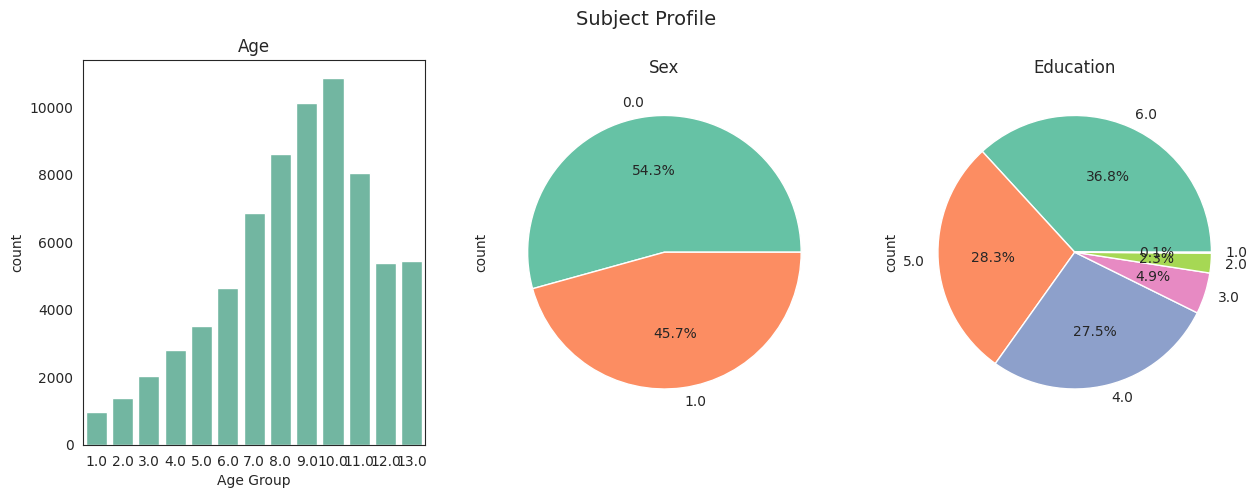

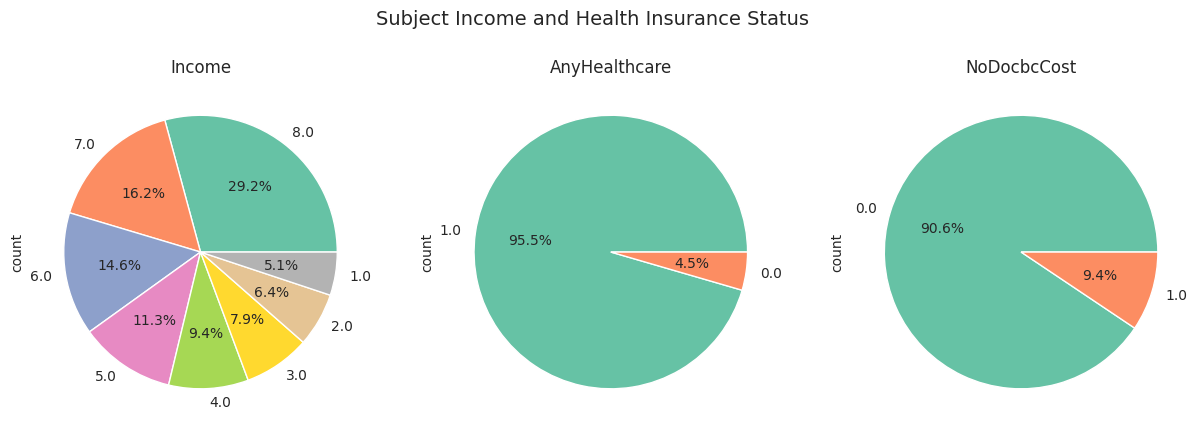

In [14]:
# Let's first check the social and economic status of the subjects

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes = axes.flatten()
sns.countplot(x='Age', data=train, ax=axes[0])
axes[0].set_title('Age')
axes[0].set_xlabel('Age Group')

for i, col in enumerate(['Sex', 'Education']):
    train[col].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[i+1], title=col)
plt.suptitle('Subject Profile', fontsize=14)
plt.show()

# what are the
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes = axes.flatten()
for i, col in enumerate(['Income', 'AnyHealthcare', 'NoDocbcCost']):
    train[col].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[i], title=col)
plt.suptitle('Subject Income and Health Insurance Status', fontsize=14)
plt.show()

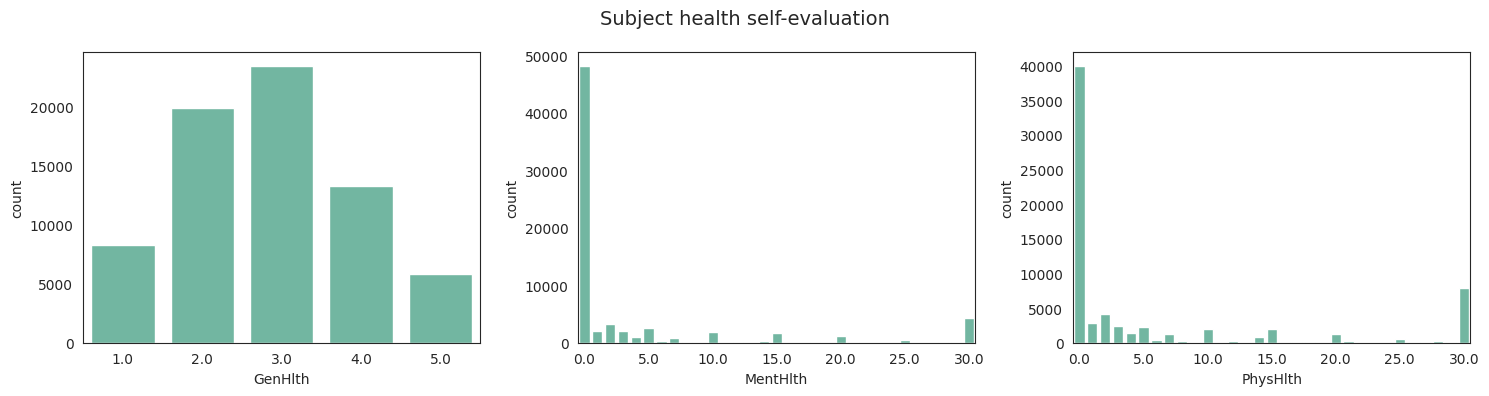

In [15]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes = axes.flatten()
for i, col in enumerate(cat_health):
    g = sns.countplot(x=col, data=train, ax=axes[i])
    if len(train[col].unique()) > 5:
        g.set_xticks(np.arange(0, len(train[col].unique()), 5))
plt.suptitle('Subject health self-evaluation', fontsize=14)
plt.tight_layout()
plt.show()

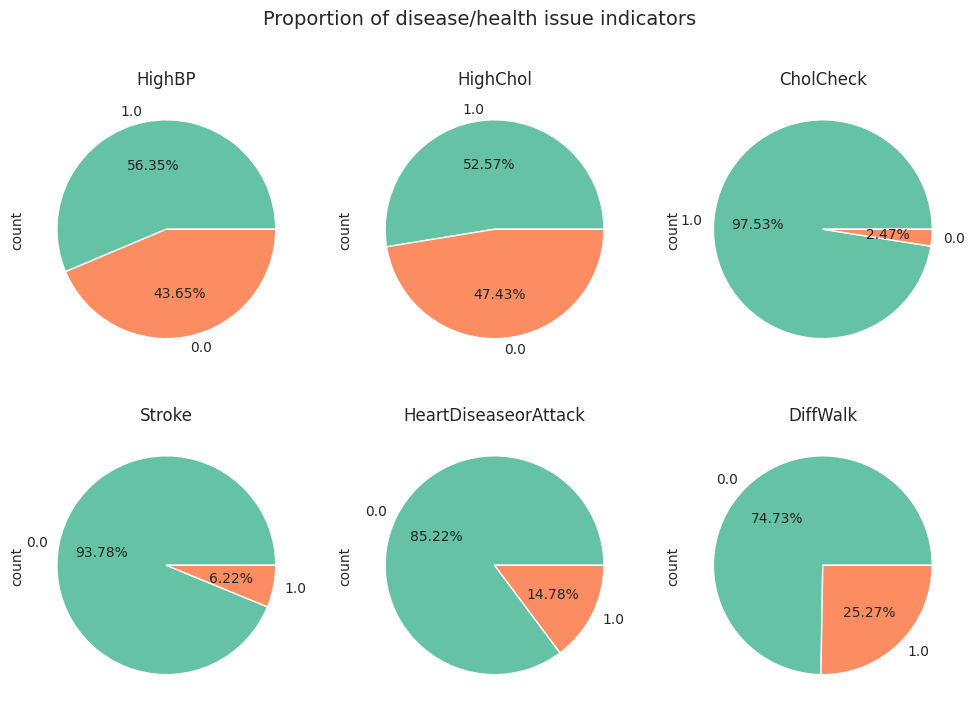

In [16]:

fig, ax = plt.subplots(2, 3, figsize=(12, 8))
for i, col in enumerate(cat_disease):
    train[col].value_counts().plot.pie(ax=ax[i//3, i%3], autopct='%.2f%%', title=col)
plt.suptitle('Proportion of disease/health issue indicators', fontsize=14)
plt.show()


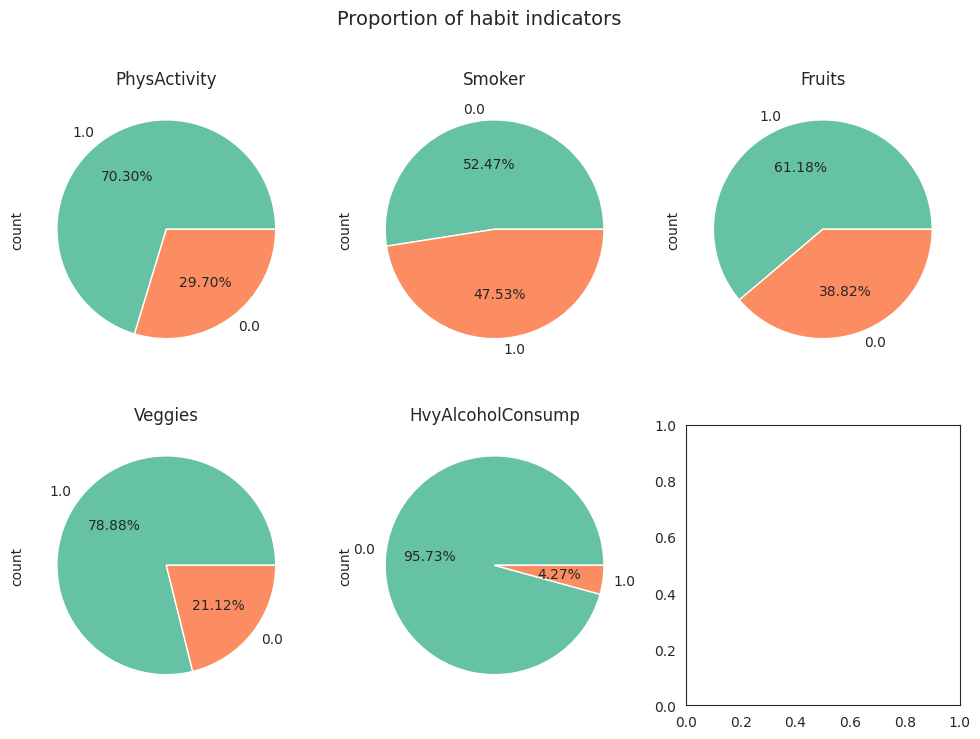

In [17]:

fig, ax = plt.subplots(2, 3, figsize=(12, 8))
for i, col in enumerate(cat_habit):
    train[col].value_counts().plot.pie(ax=ax[i//3, i%3], autopct='%.2f%%', title=col)
plt.suptitle('Proportion of habit indicators', fontsize=14)
plt.show()


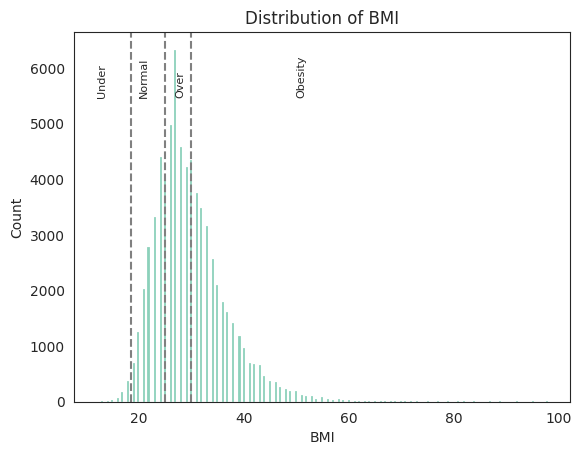

In [18]:
# plot the distribution of BMI

plt.axvline(18.5, color='gray', linestyle='--')
plt.axvline(24.9, color='gray', linestyle='--')
plt.axvline(29.9, color='gray', linestyle='--')

# add text
plt.text(12, 5500, 'Under', rotation=90, size=8)
plt.text(20, 5500, 'Normal', rotation=90, size=8)
plt.text(27, 5500, 'Over', rotation=90, size=8)
plt.text(50, 5500, 'Obesity', rotation=90, size=8)

sns.histplot(train['BMI'], kde=False)

plt.title('Distribution of BMI')
plt.show()

# Relationship between features and target

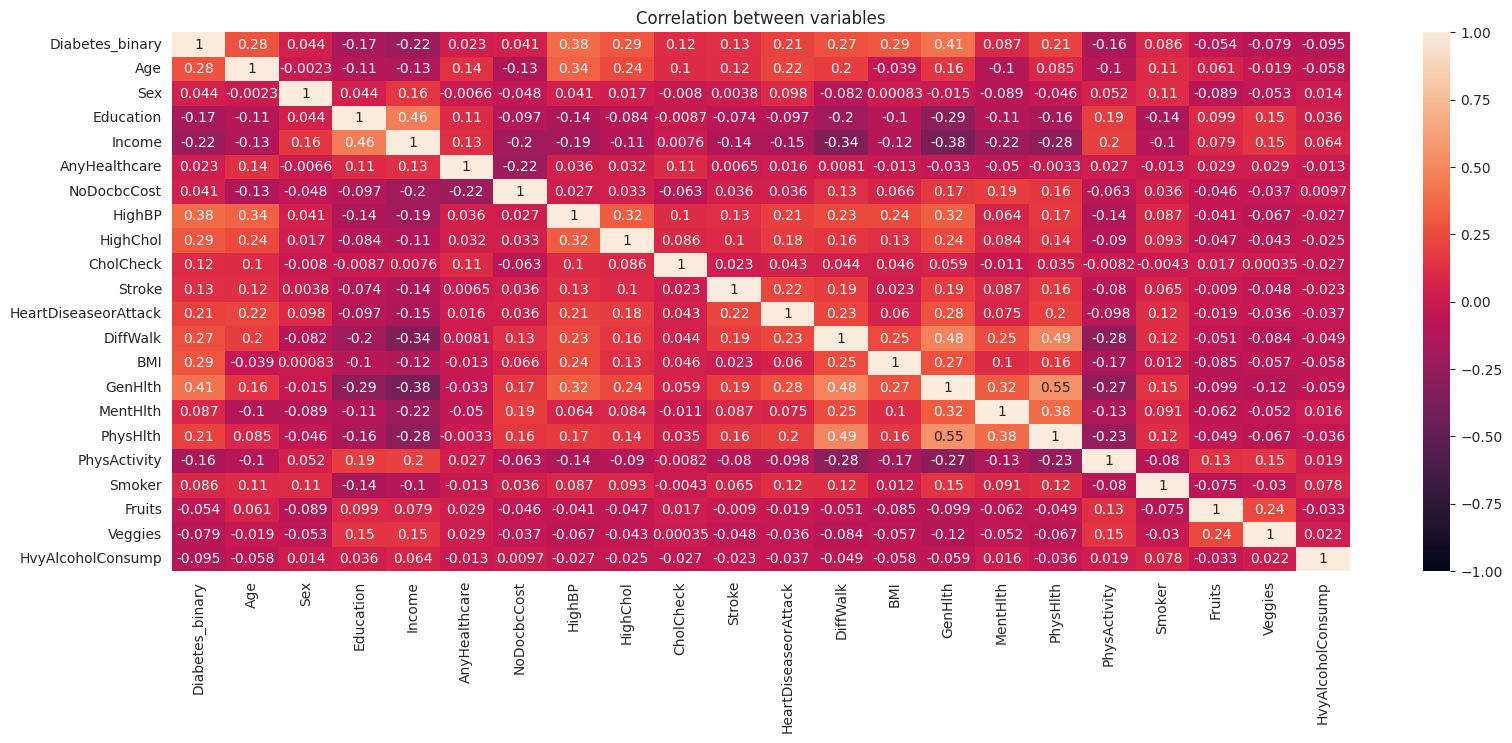

In [19]:
# plot a heatmap to check the correlation between the variables


cols = ['Diabetes_binary'] + cat_socialandeconomical + cat_disease +  ['BMI'] + cat_health + cat_habit

plt.figure(figsize=(19, 7))
# nomralize the color scale
sns.heatmap(train[cols].corr(), annot=True,  vmin=-1, vmax=1)
plt.title('Correlation between variables')
plt.show()


In [20]:

train.corr()['Diabetes_binary'].abs().sort_values(ascending=False).head(15)


,Diabetes_binary
Diabetes_binary,1.000000
GenHlth,0.407612
HighBP,0.381516
BMI,0.293373
HighChol,0.289213
Age,0.278738
DiffWalk,0.272646
Income,0.224449
PhysHlth,0.213081
HeartDiseaseorAttack,0.211523


## Data preprocessing

In [21]:
# split the data into X and y
X = train.drop('Diabetes_binary', axis=1)
y = train['Diabetes_binary']

# split the data into train and validation set
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

X_test = test.drop('Diabetes_binary', axis=1)
y_test = test['Diabetes_binary']

In [22]:
# feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)



In [23]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [24]:
from sklearn.ensemble import AdaBoostClassifier
adaboost = AdaBoostClassifier( n_estimators=50, random_state=42)
adaboost.fit(X_train, y_train)
y_pred = adaboost.predict(X_test)
acc1=accuracy_score(y_test,y_pred)
acc1

0.7267423525701672

Text(0.5, 1.03, 'Confusion Matrix for Adaboost Classifier')

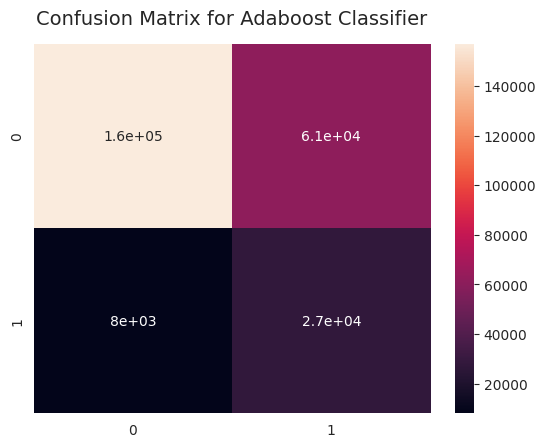

In [25]:
cf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cf_matrix, annot=True)
plt.title("Confusion Matrix for Adaboost Classifier", fontsize=14, fontname="DejaVu Sans", y=1.03)

In [26]:
print ("Accuracy: " + str(accuracy_score(y_pred, y_test)))
print ("Precision: " + str(precision_score(y_pred, y_test)))
print ("Recall: " + str(recall_score(y_pred, y_test)))
print ("F1: " + str(f1_score(y_pred, y_test)))

Accuracy: 0.7267423525701672
Precision: 0.7731002093589091
Recall: 0.30832938415363437
F1: 0.440841480334269


In [27]:
!pip3 install catboost

In [28]:
from catboost import CatBoostClassifier
catboost = CatBoostClassifier(iterations=100, depth=6, learning_rate=0.1, random_seed=42)
catboost.fit(X_train,y_train)
y_pred2 =  catboost.predict(X_test)
acc2=accuracy_score(y_test,y_pred2)


0:	learn: 0.6573129	total: 82.5ms	remaining: 8.17s
1:	learn: 0.6288979	total: 113ms	remaining: 5.52s
2:	learn: 0.6072896	total: 149ms	remaining: 4.8s
3:	learn: 0.5893133	total: 184ms	remaining: 4.42s
4:	learn: 0.5760171	total: 212ms	remaining: 4.04s
5:	learn: 0.5647028	total: 225ms	remaining: 3.53s
6:	learn: 0.5556077	total: 238ms	remaining: 3.16s
7:	learn: 0.5477340	total: 250ms	remaining: 2.87s
8:	learn: 0.5417821	total: 261ms	remaining: 2.63s
9:	learn: 0.5366154	total: 278ms	remaining: 2.5s
10:	learn: 0.5320821	total: 300ms	remaining: 2.42s
11:	learn: 0.5278829	total: 324ms	remaining: 2.38s
12:	learn: 0.5247031	total: 351ms	remaining: 2.35s
13:	learn: 0.5223120	total: 375ms	remaining: 2.3s
14:	learn: 0.5199222	total: 402ms	remaining: 2.27s
15:	learn: 0.5176893	total: 427ms	remaining: 2.24s
16:	learn: 0.5158574	total: 454ms	remaining: 2.22s
17:	learn: 0.5140433	total: 477ms	remaining: 2.17s
18:	learn: 0.5125715	total: 491ms	remaining: 2.09s
19:	learn: 0.5110900	total: 500ms	remaining

In [29]:
acc2

0.719769000315358

In [30]:
print ("Accuracy: " + str(accuracy_score(y_pred2, y_test)))
print ("Precision: " + str(precision_score(y_pred2, y_test)))
print ("Recall: " + str(recall_score(y_pred2, y_test)))
print ("F1: " + str(f1_score(y_pred2, y_test)))

Accuracy: 0.719769000315358
Precision: 0.8047586714196797
Recall: 0.3070719937819136
F1: 0.4445260550559076


Text(0.5, 1.03, 'Confusion Matrix for Catboostboost Classifier')

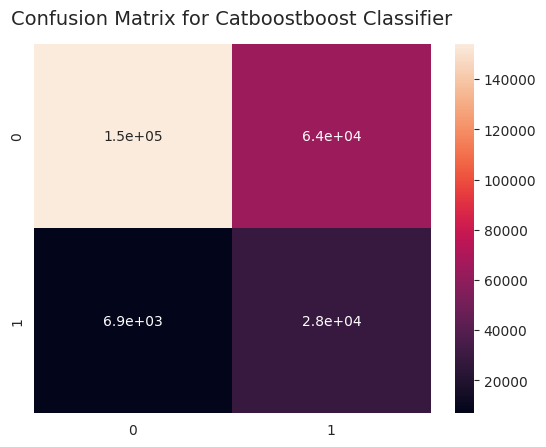

In [31]:
cf_matrix = confusion_matrix(y_test, y_pred2)
sns.heatmap(cf_matrix, annot=True)
plt.title("Confusion Matrix for Catboostboost Classifier", fontsize=14, fontname="DejaVu Sans", y=1.03)

In [32]:

from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier().fit(X_train, y_train)
dt.fit(X_train,y_train)
y_pred3 =  dt.predict(X_test)
acc3=accuracy_score(y_test,y_pred3)

In [33]:
acc3

0.7326631977294229

In [34]:
print ("Accuracy: " + str(accuracy_score(y_pred3, y_test)))
print ("Precision: " + str(precision_score(y_pred3, y_test)))
print ("Recall: " + str(recall_score(y_pred3, y_test)))
print ("F1: " + str(f1_score(y_pred3, y_test)))

Accuracy: 0.7326631977294229
Precision: 0.9232444972557008
Recall: 0.33388242034827803
F1: 0.49041207057196956


Text(0.5, 1.03, 'Confusion Matrix for Decision tree Classifier')

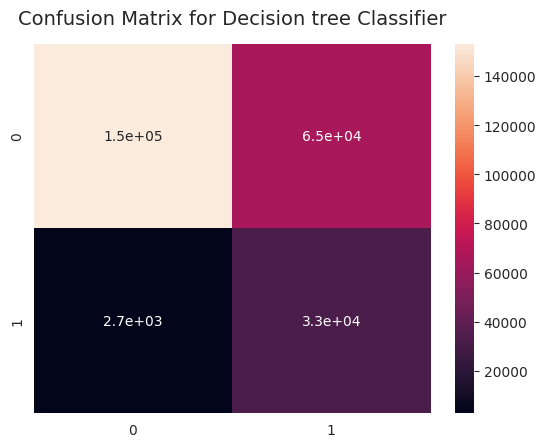

In [35]:
cf_matrix = confusion_matrix(y_test, y_pred3)
sns.heatmap(cf_matrix, annot=True)
plt.title("Confusion Matrix for Decision tree Classifier", fontsize=14, fontname="DejaVu Sans", y=1.03)

In [36]:
from sklearn.svm import SVC
svm= SVC(random_state=0)
svm.fit(X_train, y_train)

SVC(random_state=0)

In [37]:
y_pred4 =  svm.predict(X_test)
acc4=accuracy_score(y_test,y_pred4)

In [38]:
acc4

0.7108128350678019

In [39]:
print ("Accuracy: " + str(accuracy_score(y_pred4, y_test)))
print ("Precision: " + str(precision_score(y_pred4, y_test)))
print ("Recall: " + str(recall_score(y_pred4, y_test)))
print ("F1: " + str(f1_score(y_pred4, y_test)))

Accuracy: 0.7108128350678019
Precision: 0.8150851581508516
Recall: 0.3012495425315
F1: 0.4399111321489376


Text(0.5, 1.03, 'Confusion Matrix for SVM')

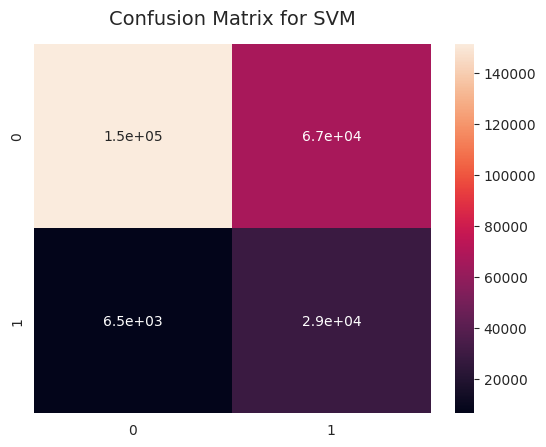

In [40]:
cf_matrix = confusion_matrix(y_test, y_pred4)
sns.heatmap(cf_matrix, annot=True)
plt.title("Confusion Matrix for SVM", fontsize=14, fontname="DejaVu Sans", y=1.03)

In [41]:
log = LogisticRegression(solver = "liblinear")
log.fit(X_train, y_train)
y_pred5= log.predict(X_test)
acc5= accuracy_score(y_test, y_pred5)

In [42]:
acc5

0.7300417849258909

In [43]:
print ("Accuracy: " + str(accuracy_score(y_pred5, y_test)))
print ("Precision: " + str(precision_score(y_pred5, y_test)))
print ("Recall: " + str(recall_score(y_pred5, y_test)))
print ("F1: " + str(f1_score(y_pred5, y_test)))

Accuracy: 0.7300417849258909
Precision: 0.7686584054772817
Recall: 0.3105915975993141
F1: 0.4424161991841786


Text(0.5, 1.03, 'Confusion Matrix for  Logistic Regression')

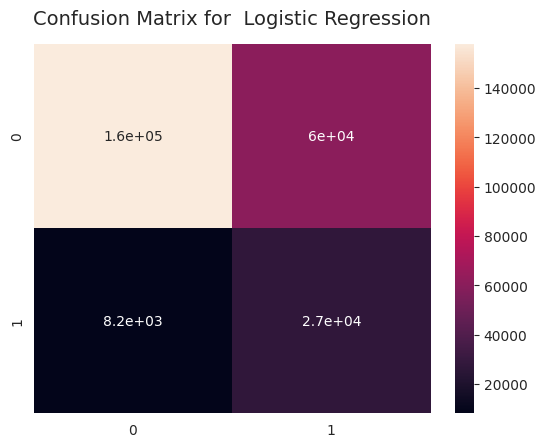

In [44]:
cf_matrix = confusion_matrix(y_test, y_pred5)
sns.heatmap(cf_matrix, annot=True)
plt.title("Confusion Matrix for  Logistic Regression", fontsize=14, fontname="DejaVu Sans", y=1.03)

In [45]:
!pip install shap


In [56]:
# Step 1 — Import libraries
import shap
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [58]:

# STEP 1 — Ensure X_test is DataFrame
# ----------------------------
# If your X_test is numpy → convert it
if isinstance(X_test, np.ndarray):
    X_test = pd.DataFrame(X_test, columns=X.columns)  # use original column names




In [59]:
# STEP 2 — Take small sample FIRST (for speed)
# ----------------------------
X_sample = X_test.sample(n=100, random_state=42)



In [60]:
# STEP 3 — Create explainer
# ----------------------------
explainer = shap.TreeExplainer(model)


In [61]:

# STEP 4 — Get SHAP values ONLY for sample
# ----------------------------
shap_values = explainer.shap_values(X_sample)


In [66]:
# Handle ALL possible SHAP output formats
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]

elif len(shap_values.shape) == 3:
    shap_values_to_plot = shap_values[:, :, 1]

else:
    shap_values_to_plot = shap_values

In [67]:
print(X_sample.shape)
print(shap_values_to_plot.shape)

(100, 21)
(100, 21)


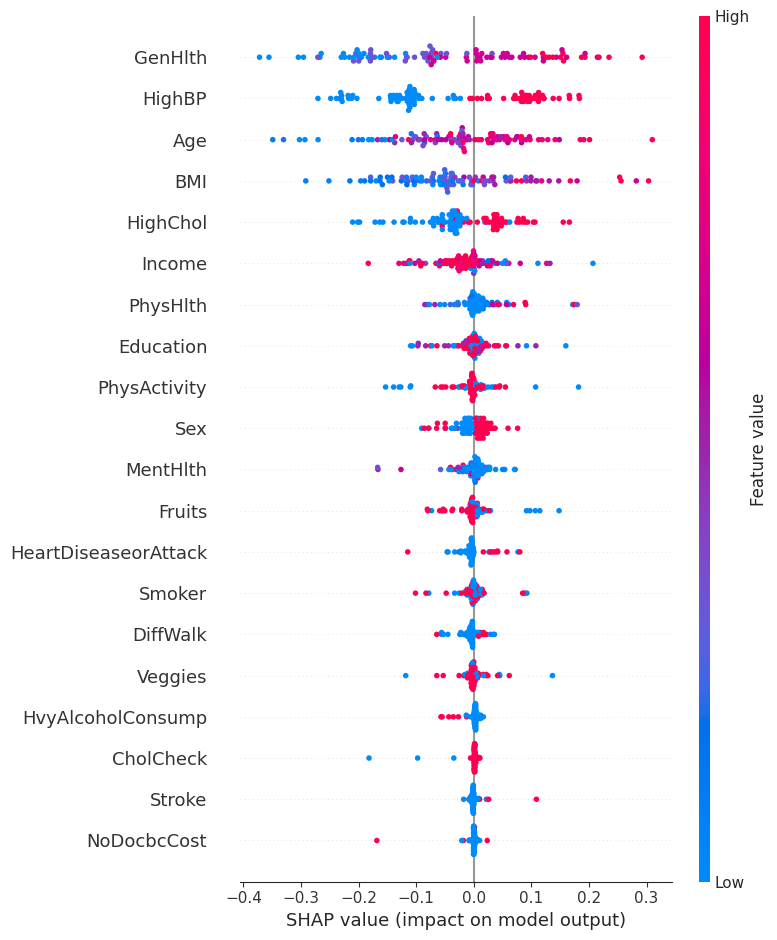

In [68]:
plt.figure()
shap.summary_plot(shap_values_to_plot, X_sample, show=False)

plt.savefig("shap_summary_diabetes.png", bbox_inches='tight', dpi=300)

plt.show()

In [69]:
print(X_sample.shape)
print(shap_values_to_plot.shape)

(100, 21)
(100, 21)
